# Residual Learning, Receptive Field, and UNet

This notebook develops the next steps beyond a plain CNN. We first discuss residual learning and why learning the artifact can be easier than learning the clean image directly. We then introduce the receptive field as a key design concept and conclude with the UNet architecture, which is often the strongest default choice for end-to-end image reconstruction.


### Residual CNN

Any CNN for image processing works by identifying **patterns** in the input image, which have been previously learned during training, and by reconstructing each pattern in the same way it was learned. For this reason, if, for example, we train a model to deblur images of cats, there is no guarantee that the same model will be able to deblur images of dogs: the different patterns present in dog images make accurate reconstruction much harder.

Consequently, a large line of research in CNN-based image processing tries to teach models to identify patterns that are typical of the **task** one wants to solve, rather than patterns that are specific to the training data. To this end, we can observe that while the patterns in the image are usually dataset-specific, the **artifact** (i.e. the difference between the corrupted image and the true image) tends to exhibit task-related patterns.

For example, consider the following problem, where two images coming from two completely different datasets are corrupted by Gaussian blur and noise. By looking at both the true image and the corrupted image, it is clear that the **content** of the two examples is very different.
On the other hand, when we look at the **residual**, i.e. the value $|x_{true} - y^\delta|$, the patterns in the two images look similar.

This observation justifies that **learning the residual is usually easier (and generalizes better) than learning the actual image**.


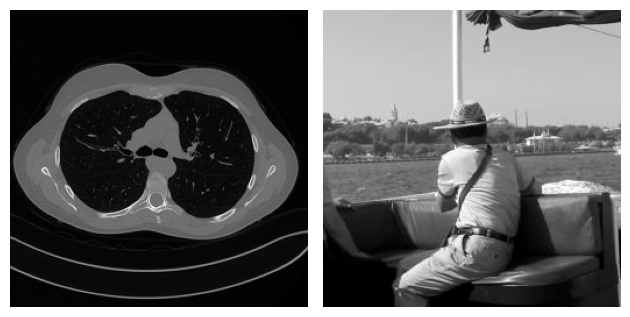

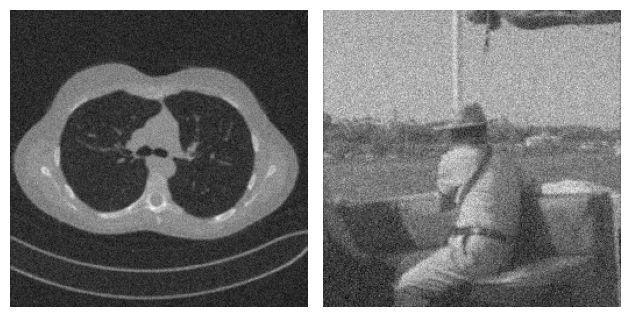

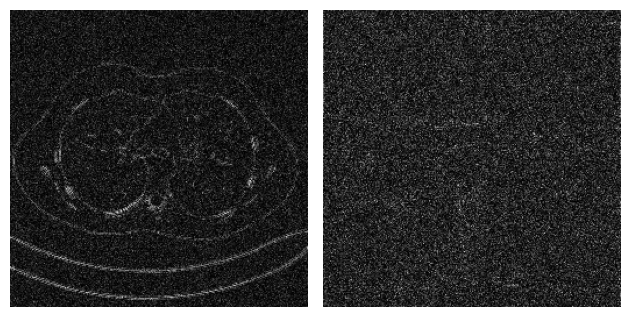

In [6]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image

sys.path.append('..')
from IPPy import operators, utilities

img_dir = Path('..') / 'imgs'

# Load images explicitly from disk as grayscale arrays.
x_mayo = Image.open(img_dir / 'Mayo.png').convert('L')
x_mayo = torch.tensor(np.array(x_mayo), dtype=torch.float32).unsqueeze(0).unsqueeze(0)
x_mayo = F.interpolate(x_mayo, size=(256, 256), mode='bilinear', align_corners=False)
x_mayo = (x_mayo - x_mayo.min()) / (x_mayo.max() - x_mayo.min())

x_gopro = Image.open(img_dir / 'GoPro.jpg').convert('L')
x_gopro = torch.tensor(np.array(x_gopro), dtype=torch.float32).unsqueeze(0).unsqueeze(0)
x_gopro = F.interpolate(x_gopro, size=(256, 256), mode='bilinear', align_corners=False)
x_gopro = (x_gopro - x_gopro.min()) / (x_gopro.max() - x_gopro.min())

# Visualize the clean images.
plt.subplot(1, 2, 1)
plt.imshow(x_mayo.squeeze(), cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(x_gopro.squeeze(), cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

# Corrupt and add noise.
K = operators.Blurring(img_shape=(256, 256), kernel_type='gaussian', kernel_size=3, kernel_variance=1)

y_mayo = K(x_mayo)
y_mayo_delta = y_mayo + utilities.gaussian_noise(y_mayo, noise_level=0.2)

y_gopro = K(x_gopro)
y_gopro_delta = y_gopro + utilities.gaussian_noise(y_gopro, noise_level=0.2)

# Visualize the corrupted images.
plt.subplot(1, 2, 1)
plt.imshow(y_mayo_delta.squeeze(), cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(y_gopro_delta.squeeze(), cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

# Visualize the residuals.
plt.subplot(1, 2, 1)
plt.imshow(torch.abs(y_mayo_delta - x_mayo).squeeze(), cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(torch.abs(y_gopro_delta - x_gopro).squeeze(), cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()


With this idea in mind, some authors developed a variant of the simple CNN architecture discussed above, in which the network is trained to learn **not** the reconstructed image itself, but rather the **residual**, which is then converted into the actual image by simply adding the corrupted image $y^\delta$ back to the output of the model. The operation of summing the input back into the output with the aim of learning the residual is usually called a **residual connection** or **skip connection**. These architectures are called **Residual Convolutional Neural Networks (ResCNNs)**.

```{image} /imgs/ResCNN.png
:width: 800px
:align: center
```

What follows is a PyTorch implementation of a ResCNN architecture with the same basic structure as the CNN discussed previously. Note that we employ Tanh as the final activation function for this task, as already discussed in the previous section.


In [7]:
import torch
from torch import nn

class ResCNN(nn.Module):
    def __init__(self, in_ch, out_ch, n_filters, kernel_size=3):
        super().__init__()

        # Define (convolution) layers -> NOTE: padding="same" means "padded convolution"
        self.conv1 = nn.Conv2d(in_channels=in_ch, out_channels=n_filters, kernel_size=kernel_size, padding="same")
        self.conv2 = nn.Conv2d(in_channels=n_filters, out_channels=n_filters, kernel_size=kernel_size, padding="same")
        self.conv3 = nn.Conv2d(in_channels=n_filters, out_channels=out_ch, kernel_size=kernel_size, padding="same")

        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self, x):
        h = self.relu(self.conv1(x))
        h = self.relu(self.conv2(h))
        out = self.tanh(self.conv3(h))
        return out + x

Training a residual model follows exactly the same logic as for the plain CNN, but now the network learns a correction to be added back to the corrupted input. The code below trains a `ResCNN` for 50 epochs on the Mayo motion-blur task, saves the learned parameters in `../weights/ResCNN.pth`, reloads them, and visualizes one reconstruction together with the loss history.


Epoch 20/20: 100%|██████████| 414/414 [03:07<00:00,  2.21it/s, avg_loss=0.000317, batch_loss=0.000319]


Saved ResCNN weights to: C:\Users\tivog\computational-imaging\years\2025-26\weights\ResCNN.pth


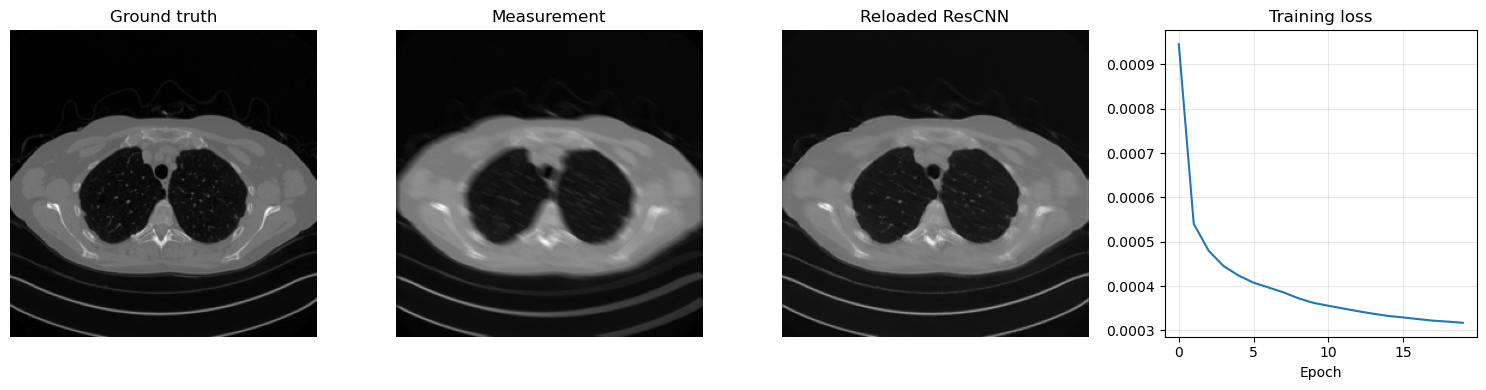

In [8]:
import glob
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

sys.path.append('..')
from IPPy import operators, utilities

book_root = Path('..').resolve()
weights_dir = book_root / 'weights'
weights_dir.mkdir(exist_ok=True)

class MayoDataset(Dataset):
    def __init__(self, data_path, data_shape):
        super().__init__()
        self.data_path = data_path
        self.data_shape = data_shape
        self.fname_list = glob.glob(f'{data_path}/*/*.png')

    def __len__(self):
        return len(self.fname_list)

    def __getitem__(self, idx):
        img_path = self.fname_list[idx]
        x = Image.open(img_path).convert('L')
        x = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize(self.data_shape),
        ])(x)
        return x

device = utilities.get_device()
train_dataset = MayoDataset(data_path=str(book_root / 'Mayo' / 'train'), data_shape=256)
test_dataset = MayoDataset(data_path=str(book_root / 'Mayo' / 'test'), data_shape=256)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

K = operators.Blurring(
    img_shape=(256, 256),
    kernel_type='motion',
    kernel_size=9,
    motion_angle=20,
)

torch.manual_seed(0)
model = ResCNN(in_ch=1, out_ch=1, n_filters=32, kernel_size=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

num_epochs = 20
noise_level = 0.01
history = []
weights_path = weights_dir / 'ResCNN.pth'

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}', leave=True)

    for step, x_batch in enumerate(progress_bar, start=1):
        x_batch = x_batch.to(device)

        with torch.no_grad():
            y_batch = K(x_batch)
            y_batch = y_batch + utilities.gaussian_noise(y_batch, noise_level=noise_level)

        prediction = model(y_batch)
        loss = loss_fn(prediction, x_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(batch_loss=f'{loss.item():.6f}', avg_loss=f'{epoch_loss / step:.6f}')

    history.append(epoch_loss / len(train_loader))

torch.save(model.state_dict(), weights_path)
print(f'Saved ResCNN weights to: {weights_path}')

reloaded_model = ResCNN(in_ch=1, out_ch=1, n_filters=32, kernel_size=3)
reloaded_model.load_state_dict(torch.load(weights_path, map_location='cpu', weights_only=True))
reloaded_model = reloaded_model.to(device)
reloaded_model.eval()

with torch.no_grad():
    x_true = next(iter(test_loader))[0:1].to(device)
    y_delta = K(x_true)
    y_delta = y_delta + utilities.gaussian_noise(y_delta, noise_level=noise_level)
    x_rec = reloaded_model(y_delta)

plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1)
plt.imshow(x_true.cpu().squeeze(), cmap='gray')
plt.title('Ground truth')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(y_delta.cpu().squeeze(), cmap='gray')
plt.title('Measurement')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(x_rec.cpu().squeeze(), cmap='gray')
plt.title('Reloaded ResCNN')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.plot(history)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Beyond CNN: the Receptive field

Modern neural-network architectures for image-processing tasks rarely use the simple CNN model described above. One reason is the concept of **Receptive Field (RF)**. To understand it, let us consider a model with $L$ convolutional layers, each with kernel size $\kappa_l = 3$, as depicted in the following figure. It is evident that each pixel in the feature map of the second layer is influenced only by a $3 \times 3$ portion of the first layer, that is, the input of the network. Similarly, each pixel in the feature map of the third layer is influenced by a $3 \times 3$ portion of the previous layer, and consequently by a $5 \times 5$ portion of the input image. The number of input-image pixels that affect the value of each pixel in the $l$-th feature map is what we call the receptive field of the $l$-th layer. By continuing this reasoning through the network up to the output, we can compute the receptive field of the whole network, which represents the number of input-image pixels that influence the network's output. This quantity is crucial because, when reconstructing corrupted data containing artifacts, understanding the RF helps ensure that the model captures and addresses those artifacts accurately. In particular, when the artifacts are local, a small receptive field is enough to give the model the ability to distinguish between the artifact and the image features, while when the artifacts are global, a large RF is required to produce an accurate reconstruction.

```{image} /imgs/receptive_field.png
:width: 95%
:align: center
```

Since we are interested in comparing neural network architectures in terms of their receptive field, we need to derive a formula to compute it for any given network. For each layer $l$, let $\kappa_l$ and $s_l$ be its kernel size and stride, respectively. Moreover, let $r_l$ be the receptive field, where the receptive field of the input layer is $r_0 = 1$ by definition. The value of $r_l$ can be computed with the recursive formula:

$$
    r_l = r_{l-1} + A_l,
$$

where $A_l$ is the non-overlapping area between subsequent filter applications. Note that $A_l$ can be computed simply as

$$
    A_l = (k_l - 1) \prod_{i=1}^l s_i,
$$

which implies that the receptive field at each $l$-th layer is:

$$
\begin{aligned}
    &r_0 = 1 \\
    &r_l = r_{l-1} + (k_l - 1) \prod_{i=1}^l s_i.
\end{aligned}
$$

This equation shows that the receptive field scales linearly with the depth of the network if the kernel size is fixed, while it is exponentially related to the stride. For this reason, using strided convolutional layers exponentially enlarges the receptive field of the model.


## UNet

Combining all the information discussed above, we are now ready to introduce arguably the most important neural-network model ever developed for image reconstruction: **UNet**. The UNet is a multi-scale variant of the Convolutional Neural Network architecture, and it is able to detect and correct both global and local artifacts effectively. Its central idea is simple but extremely powerful: instead of processing the image at a single resolution, the network analyzes it across a hierarchy of scales and then recombines the information while reconstructing the output.

At a high level, a UNet is a **fully convolutional encoder-decoder architecture**. The encoder progressively reduces the spatial resolution through downsampling operations, while simultaneously increasing the number of feature channels. This makes the representation more compact and enlarges the receptive field quickly. The decoder then reverses the process, progressively restoring spatial resolution until the output has the same size as the input. In imaging inverse problems, this multi-scale mechanism is particularly effective because many artifacts are neither purely local nor purely global: they can have fine edges, wide spatial extent, and interactions across multiple scales.

More formally, the encoder naturally divides the network into distinct resolution levels, which we denote by $g$, with $g = 0, \dots, \mathcal{G}$, where $\mathcal{G}+1$ is the total number of levels in the network. At each level, the number of channels is usually increased as the resolution decreases. If $c_0$ denotes the number of channels in the first level, a very common choice is

$$
    c_{g+1} = 2 c_g, \qquad g = 0, \dots, \mathcal{G} - 1.
$$

This is one of the reasons why UNets remain computationally manageable: the deeper layers have many channels, but they operate on much smaller spatial grids.

The most characteristic feature of the UNet is the presence of **skip connections between encoder and decoder levels**. When feature maps are downsampled, some high-frequency spatial information is inevitably compressed. The skip connections transfer feature maps from the encoder directly to the decoder at the same resolution level, allowing the reconstruction path to recover fine details that would otherwise be difficult to rebuild. In practice, these skip connections are one of the main reasons for the success of the architecture in segmentation, denoising, deblurring, tomography, and many other image-to-image tasks.

A second important design choice concerns the **bottleneck**. The deepest portion of the network is where the receptive field is largest and where the model can combine the widest contextual information. In inverse problems, this is often the place where the network resolves ambiguities that cannot be handled by local filters alone. For this reason, even relatively small changes in the bottleneck design can affect performance significantly.

```{image} /imgs/UNet.png
:width: 95%
:align: center
```

### Why UNet Works So Well

The practical strength of the UNet comes from the combination of three ingredients:

1. a rapidly increasing receptive field through downsampling;
2. preservation of fine spatial detail through skip connections;
3. efficient local refinement through convolutions in the decoder.

A plain CNN is often too local. A pure encoder may lose too much detail. A plain decoder may be unable to reconstruct sharp structures reliably. The UNet combines all three aspects in a relatively simple architecture, which is why it is so often the default choice in imaging applications.

### Common UNet Variants

The implementation below focuses on the most classical and simplest version of the architecture: plain convolutional blocks, max pooling, transposed convolutions, and concatenation-based skip connections. This is the right starting point for students.

After this basic version is understood, one can introduce many useful variants:

- **Residual UNet:** residual connections are added inside blocks or globally across the network to make optimization easier.
- **Attention UNet:** attention gates are inserted, typically in the deeper levels, to help the model emphasize the most relevant features.
- **UNet++:** the skip connections are redesigned into a denser nested structure, reducing the semantic gap between encoder and decoder features.
- **3D UNet:** the same multi-scale idea is extended to volumetric data, which is especially important in medical imaging.

In practice, one should not think of the UNet as a single rigid architecture, but rather as a family of encoder-decoder designs built around multi-scale processing and skip connections.


### Baseline UNet

To make the architecture explicit for teaching, we now implement a plain UNet directly in PyTorch rather than importing it from `IPPy`. The version below is intentionally simple:

- each resolution level uses a standard two-convolution block;
- downsampling is done by max pooling;
- upsampling is done by transposed convolutions;
- skip connections are implemented through concatenation;
- there are **no** residual blocks and **no** attention blocks.

This is the most classical form of UNet and is the right starting point for students. It already captures the main reason why the architecture is so successful: it combines a large receptive field in the deeper layers with high-resolution detail recovery through skip connections.

From a modeling point of view, this baseline UNet should be understood as the reference architecture against which later variants are compared. The motivation for introducing variants is usually not to replace the UNet idea, but to refine one specific aspect of it: optimization, feature selection, or skip-connection design.


Epoch 10/10: 100%|██████████| 414/414 [16:07<00:00,  2.34s/it, avg_loss=0.000072, batch_loss=0.000057]


Saved weights to: C:\Users\tivog\computational-imaging\years\2025-26\weights\UNet.pth
Total trainable parameters: 1925025


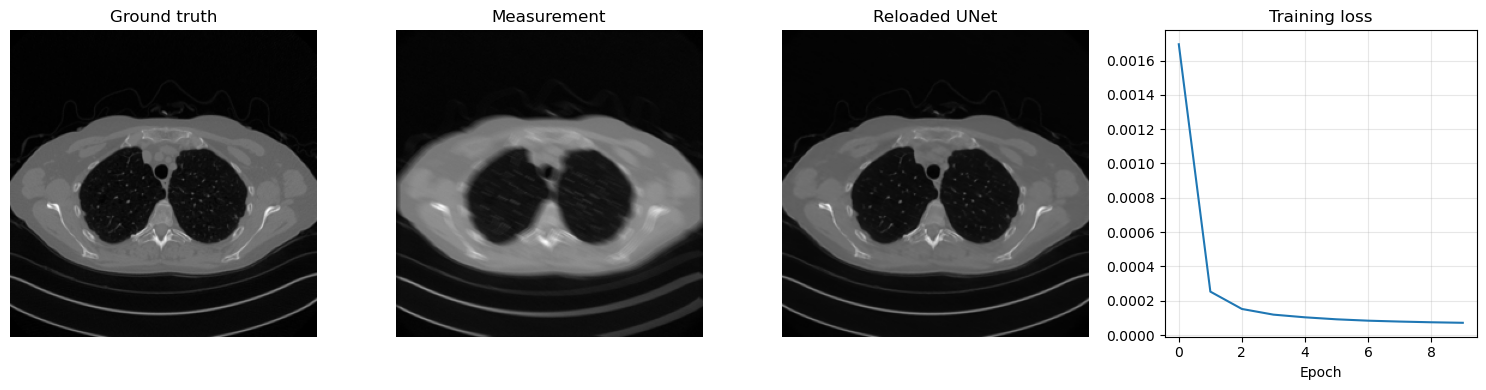

In [10]:
import torch.nn.functional as F
from tqdm.auto import tqdm

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.block(x)


class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, block_cls=DoubleConv):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.block = block_cls(in_ch, out_ch)

    def forward(self, x):
        return self.block(self.pool(x))


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, block_cls=DoubleConv):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.block = block_cls(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        x = torch.cat([skip, x], dim=1)
        return self.block(x)


class SimpleUNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base_ch=32):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base_ch)
        self.enc2 = DownBlock(base_ch, 2 * base_ch)
        self.enc3 = DownBlock(2 * base_ch, 4 * base_ch)
        self.bottleneck = DownBlock(4 * base_ch, 8 * base_ch)
        self.dec3 = UpBlock(8 * base_ch, 4 * base_ch, 4 * base_ch)
        self.dec2 = UpBlock(4 * base_ch, 2 * base_ch, 2 * base_ch)
        self.dec1 = UpBlock(2 * base_ch, base_ch, base_ch)
        self.out_conv = nn.Conv2d(base_ch, out_ch, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        h = self.bottleneck(s3)
        h = self.dec3(h, s3)
        h = self.dec2(h, s2)
        h = self.dec1(h, s1)
        return self.out_conv(h)


def train_and_reload(model, weights_path, num_epochs=20, noise_level=0.01, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}', leave=True)

        for step, x_batch in enumerate(progress_bar, start=1):
            x_batch = x_batch.to(device)

            with torch.no_grad():
                y_batch = K(x_batch)
                y_batch = y_batch + utilities.gaussian_noise(y_batch, noise_level=noise_level)

            prediction = model(y_batch)
            loss = loss_fn(prediction, x_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            progress_bar.set_postfix(batch_loss=f'{loss.item():.6f}', avg_loss=f'{epoch_loss / step:.6f}')

        history.append(epoch_loss / len(train_loader))

    torch.save(model.state_dict(), weights_path)
    print(f'Saved weights to: {weights_path}')

    reloaded_model = type(model)()
    reloaded_model.load_state_dict(torch.load(weights_path, map_location='cpu', weights_only=True))
    reloaded_model = reloaded_model.to(device)
    reloaded_model.eval()
    return reloaded_model, history


torch.manual_seed(0)
unet_model, unet_history = train_and_reload(SimpleUNet(in_ch=1, out_ch=1, base_ch=32), weights_dir / 'UNet.pth', num_epochs=10)

with torch.no_grad():
    x_true = next(iter(test_loader))[0:1].to(device)
    y_delta = K(x_true)
    y_delta = y_delta + utilities.gaussian_noise(y_delta, noise_level=0.01)
    x_rec = unet_model(y_delta)

num_params = sum(p.numel() for p in unet_model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {num_params}')

plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1)
plt.imshow(x_true.cpu().squeeze(), cmap='gray')
plt.title('Ground truth')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(y_delta.cpu().squeeze(), cmap='gray')
plt.title('Measurement')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(x_rec.cpu().squeeze(), cmap='gray')
plt.title('Reloaded UNet')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.plot(unet_history)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## UNet Variants

Once the plain UNet is understood, the next natural question is: *what should be modified when the baseline architecture is not enough?* Different variants of UNet answer this question in different ways.

- Some variants try to make the network **easier to optimize**.
- Some try to make the skip connections **more selective**.
- Some try to make the encoder-decoder fusion **more gradual and better aligned**.

The three variants below are among the most classical ones and are worth knowing because they represent three different design philosophies.

### Residual UNet

A first natural extension is the **Residual UNet**. The motivation is the same as for residual CNNs: instead of forcing each block to learn a full transformation from scratch, we let it learn a correction around an identity map. This often makes optimization easier and helps gradients propagate through deeper networks.

This variant is especially attractive when:

- the network becomes deeper and harder to train;
- the task is naturally phrased as artifact removal or correction;
- one wants the network to preserve stable features while refining only what needs to be changed.

In practice, residual blocks often make training more robust and can improve convergence speed. The price is a slightly more structured block design, but conceptually the architecture remains close to the baseline UNet.

```{image} /imgs/ResUNet.png
:width: 95%
:align: center
```

In the code below, we keep the same encoder-decoder structure as the plain UNet, but replace the standard convolutional blocks with residual blocks.


In [ ]:
class ResidualDoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.shortcut = nn.Conv2d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        h = self.relu(self.conv1(x))
        h = self.conv2(h)
        return self.relu(h + identity)


class ResidualUNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base_ch=32):
        super().__init__()
        self.enc1 = ResidualDoubleConv(in_ch, base_ch)
        self.enc2 = DownBlock(base_ch, 2 * base_ch, block_cls=ResidualDoubleConv)
        self.enc3 = DownBlock(2 * base_ch, 4 * base_ch, block_cls=ResidualDoubleConv)
        self.bottleneck = DownBlock(4 * base_ch, 8 * base_ch, block_cls=ResidualDoubleConv)
        self.dec3 = UpBlock(8 * base_ch, 4 * base_ch, 4 * base_ch, block_cls=ResidualDoubleConv)
        self.dec2 = UpBlock(4 * base_ch, 2 * base_ch, 2 * base_ch, block_cls=ResidualDoubleConv)
        self.dec1 = UpBlock(2 * base_ch, base_ch, base_ch, block_cls=ResidualDoubleConv)
        self.out_conv = nn.Conv2d(base_ch, out_ch, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        h = self.bottleneck(s3)
        h = self.dec3(h, s3)
        h = self.dec2(h, s2)
        h = self.dec1(h, s1)
        return self.out_conv(h)


torch.manual_seed(0)
resunet_model, resunet_history = train_and_reload(ResidualUNet(in_ch=1, out_ch=1, base_ch=32), weights_dir / 'ResidualUNet.pth', num_epochs=10)

plt.figure(figsize=(5, 3))
plt.plot(resunet_history)
plt.title('Residual UNet training loss')
plt.xlabel('Epoch')
plt.grid(alpha=0.3)
plt.show()


Epoch 3/10:   4%|▎         | 15/414 [00:41<18:13,  2.74s/it, avg_loss=0.000195, batch_loss=0.000189]

### Attention UNet

A second extension is the **Attention UNet**. The main idea is to modulate the skip connections: instead of forwarding all encoder features unchanged, the network learns gates that emphasize the features that are most relevant to the current decoder state.

The motivation here is different from the residual case. The issue is no longer mainly optimization, but **feature selection**. In a standard UNet, every skip connection forwards a large amount of information. This is often useful, but it can also pass irrelevant or weakly informative activations to the decoder. Attention gates try to filter these features and highlight the spatial structures that matter most for the reconstruction.

This can be particularly useful when:

- the image contains many structures but only some are relevant to the reconstruction task;
- the corruption is spatially nonuniform;
- one wants the decoder to focus more strongly on salient regions rather than treating all skip features equally.

```{image} /imgs/AttentionUNet.png
:width: 95%
:align: center
```

The implementation below inserts a simple attention gate before concatenating the skip features with the upsampled decoder features. This is not the most elaborate attention design possible, but it captures the central teaching idea clearly.


In [ ]:
class AttentionGate(nn.Module):
    def __init__(self, gate_ch, skip_ch, inter_ch):
        super().__init__()
        self.gate_proj = nn.Conv2d(gate_ch, inter_ch, kernel_size=1)
        self.skip_proj = nn.Conv2d(skip_ch, inter_ch, kernel_size=1)
        self.psi = nn.Conv2d(inter_ch, 1, kernel_size=1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, gate, skip):
        a = self.gate_proj(gate)
        b = self.skip_proj(skip)
        if a.shape[-2:] != b.shape[-2:]:
            a = F.interpolate(a, size=b.shape[-2:], mode='bilinear', align_corners=False)
        alpha = self.sigmoid(self.psi(self.relu(a + b)))
        return skip * alpha


class AttentionUpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.attn = AttentionGate(out_ch, skip_ch, out_ch)
        self.block = DoubleConv(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        skip = self.attn(x, skip)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        x = torch.cat([skip, x], dim=1)
        return self.block(x)


class AttentionUNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base_ch=32):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base_ch)
        self.enc2 = DownBlock(base_ch, 2 * base_ch)
        self.enc3 = DownBlock(2 * base_ch, 4 * base_ch)
        self.bottleneck = DownBlock(4 * base_ch, 8 * base_ch)
        self.dec3 = AttentionUpBlock(8 * base_ch, 4 * base_ch, 4 * base_ch)
        self.dec2 = AttentionUpBlock(4 * base_ch, 2 * base_ch, 2 * base_ch)
        self.dec1 = AttentionUpBlock(2 * base_ch, base_ch, base_ch)
        self.out_conv = nn.Conv2d(base_ch, out_ch, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        h = self.bottleneck(s3)
        h = self.dec3(h, s3)
        h = self.dec2(h, s2)
        h = self.dec1(h, s1)
        return self.out_conv(h)


torch.manual_seed(0)
attunet_model, attunet_history = train_and_reload(AttentionUNet(in_ch=1, out_ch=1, base_ch=32), weights_dir / 'AttentionUNet.pth', num_epochs=10)

plt.figure(figsize=(5, 3))
plt.plot(attunet_history)
plt.title('Attention UNet training loss')
plt.xlabel('Epoch')
plt.grid(alpha=0.3)
plt.show()


### UNet++

A third important variant is **UNet++**. Its motivation is slightly different: instead of modifying the convolutional blocks or the skip gates, it redesigns the skip connections themselves. The nested skip pathways try to reduce the **semantic gap** between encoder features and decoder features by refining them progressively before fusion.

This point is worth stressing. In a classical UNet, encoder features and decoder features at the same resolution are fused directly, even though they may represent information at rather different stages of abstraction. UNet++ addresses this mismatch by inserting intermediate convolutional refinements along the skip pathways. In this way, the decoder receives features that have already been partially adapted before the final concatenation.

This variant is attractive when:

- direct encoder-decoder fusion seems too abrupt;
- one wants richer multiscale feature aggregation;
- one is willing to pay a higher implementation and computational cost for potentially better feature alignment.

```{image} /imgs/UNetPP.png
:width: 95%
:align: center
```

A full UNet++ implementation can become quite large, so for teaching we use a compact three-level version. The key point is already visible: intermediate skip pathways are themselves processed by convolutional blocks before reaching the final decoder output.


In [ ]:
class UNetPP(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base_ch=32):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)

        self.x0_0 = DoubleConv(in_ch, base_ch)
        self.x1_0 = DoubleConv(base_ch, 2 * base_ch)
        self.x2_0 = DoubleConv(2 * base_ch, 4 * base_ch)

        self.x0_1 = DoubleConv(base_ch + 2 * base_ch, base_ch)
        self.x1_1 = DoubleConv(2 * base_ch + 4 * base_ch, 2 * base_ch)
        self.x0_2 = DoubleConv(base_ch * 2 + 2 * base_ch, base_ch)

        self.out_conv = nn.Conv2d(base_ch, out_ch, kernel_size=1)

    def forward(self, x):
        x0_0 = self.x0_0(x)
        x1_0 = self.x1_0(self.pool(x0_0))
        x2_0 = self.x2_0(self.pool(x1_0))

        x0_1 = self.x0_1(torch.cat([x0_0, self.up(x1_0)], dim=1))
        x1_1 = self.x1_1(torch.cat([x1_0, self.up(x2_0)], dim=1))
        x0_2 = self.x0_2(torch.cat([x0_0, x0_1, self.up(x1_1)], dim=1))

        return self.out_conv(x0_2)


torch.manual_seed(0)
unetpp_model, unetpp_history = train_and_reload(UNetPP(in_ch=1, out_ch=1, base_ch=32), weights_dir / 'UNetPP.pth', num_epochs=10)

plt.figure(figsize=(5, 3))
plt.plot(unetpp_history)
plt.title('UNet++ training loss')
plt.xlabel('Epoch')
plt.grid(alpha=0.3)
plt.show()


### Comparing the Variants on the Same Corrupted Image

To conclude the section, we now reconstruct the **same** corrupted test image with all four architectures: the plain UNet, the Residual UNet, the Attention UNet, and UNet++. This comparison is useful because it isolates the architectural choice while keeping the input corruption fixed.

Pedagogically, this final step matters a lot. Students should not leave the discussion with the impression that these variants are only abstract design ideas. The point is to see that small changes in block design, skip selection, or feature fusion can lead to visibly different reconstruction behavior even when the overall encoder-decoder structure remains the same.


In [ ]:
torch.manual_seed(123)

with torch.no_grad():
    x_compare = test_dataset[0].unsqueeze(0).to(device)
    y_compare = K(x_compare)
    y_compare = y_compare + utilities.gaussian_noise(y_compare, noise_level=0.01)

    recon_plain = unet_model(y_compare)
    recon_residual = resunet_model(y_compare)
    recon_attention = attunet_model(y_compare)
    recon_pp = unetpp_model(y_compare)

plt.figure(figsize=(18, 4))
plt.subplot(1, 6, 1)
plt.imshow(x_compare.cpu().squeeze(), cmap='gray')
plt.title('Ground truth')
plt.axis('off')

plt.subplot(1, 6, 2)
plt.imshow(y_compare.cpu().squeeze(), cmap='gray')
plt.title('Measurement')
plt.axis('off')

plt.subplot(1, 6, 3)
plt.imshow(recon_plain.cpu().squeeze(), cmap='gray')
plt.title('UNet')
plt.axis('off')

plt.subplot(1, 6, 4)
plt.imshow(recon_residual.cpu().squeeze(), cmap='gray')
plt.title('Residual UNet')
plt.axis('off')

plt.subplot(1, 6, 5)
plt.imshow(recon_attention.cpu().squeeze(), cmap='gray')
plt.title('Attention UNet')
plt.axis('off')

plt.subplot(1, 6, 6)
plt.imshow(recon_pp.cpu().squeeze(), cmap='gray')
plt.title('UNet++')
plt.axis('off')

plt.tight_layout()
plt.show()

for name, rec in [('UNet', recon_plain), ('Residual UNet', recon_residual), ('Attention UNet', recon_attention), ('UNet++', recon_pp)]:
    mse = torch.mean((rec - x_compare) ** 2).item()
    print(f'{name:>16} | MSE = {mse:.6f}')


## Exercises

1. Why is learning the residual often easier than learning the full image directly?
2. Consider a CNN with three convolutional layers of kernel size $3 \times 3$ and stride $1$. What is its receptive field? How does the answer change if one layer has stride $2$?
3. Explain why the receptive field is important when the corruption is global rather than local.
4. What is the main architectural idea behind UNet, and why do skip connections matter so much in imaging tasks?
5. Compare a plain UNet and a Residual UNet conceptually. What optimization advantage do residual blocks provide?
6. What is the motivation behind attention gates in an Attention UNet?
7. In your own words, what problem is UNet++ trying to solve with nested skip connections?
8. Code exercise: change the base number of channels in one or more variants and compare both the number of parameters and the reconstruction quality.
9. Code exercise: repeat the final comparison on a different corrupted test image and check whether the relative behavior of the variants changes.


## Further Reading

Residual learning is introduced in {cite}`he2016deep`. The standard reference for the UNet architecture is {cite}`ronneberger2015u`. For volumetric imaging, see the 3D UNet of {cite}`cciccek20163d`. For an attention-based variant, see {cite}`oktay2018attention`. For a nested skip-connection design, see {cite}`zhou2018unetplusplus`. For a broader discussion of why multiscale neural architectures are effective in imaging inverse problems, see {cite}`ongie2020deep`.
